In [157]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df=pd.read_csv("train.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [158]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [159]:
df.shape

(1460, 81)

In [160]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [161]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [162]:
numerical_cols=df.select_dtypes(include=["int64","float64"]).columns
len(numerical_cols)

38

In [163]:
categorical_col=df.select_dtypes(include=["str"]).columns
len(categorical_col)

43

In [164]:
df["SalePrice"].median()

np.float64(163000.0)

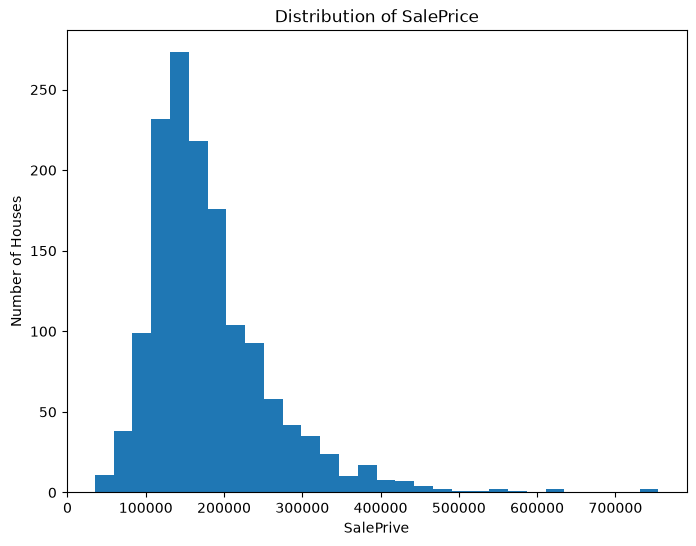

In [165]:
plt.figure(figsize=(8,6))
plt.hist(df["SalePrice"],bins=30)
plt.xlabel("SalePrive")
plt.ylabel("Number of Houses")
plt.title("Distribution of SalePrice")
plt.show()
#SalePrice is right-skewed and contains some expensive outliers.

### SalePrice Distribution

The target variable SalePrice is right-skewed.  
Most houses have prices between 100,000 and 250,000, while a few houses have very high prices.  
This means there may be outliers that can affect regression models.

In [166]:
missing_summery=pd.DataFrame({
    "Missing Count":df.isna().sum(),
    "Missing percentages":(df.isna().sum()/len(df))*100
})
missing_summery=missing_summery[missing_summery["Missing Count"]>0]
missing_summery=missing_summery.sort_values(by="Missing Count",ascending=False)
missing_summery

,Missing Count,Missing percentages
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


In [167]:
df_clean=df.copy()

In [168]:
none_cols = [
    "PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu",
    "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    "MasVnrType"
]
df_clean[none_cols ]=df_clean[none_cols].fillna("None")
df_clean["LotFrontage"] = df_clean["LotFrontage"].fillna(df_clean["LotFrontage"].median())
df_clean["GarageYrBlt"]=df["GarageYrBlt"].fillna(0)
df_clean["MasVnrArea"]=df["MasVnrArea"].fillna(0)
df_clean["Electrical"] = df_clean["Electrical"].fillna(df_clean["Electrical"].mode()[0])
df_clean.isna().sum().sum()

np.int64(0)

In [169]:
corr=df_clean.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)
top_corr=corr.drop("SalePrice").head(10)
top_corr

OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64

<Figure size 800x600 with 0 Axes>

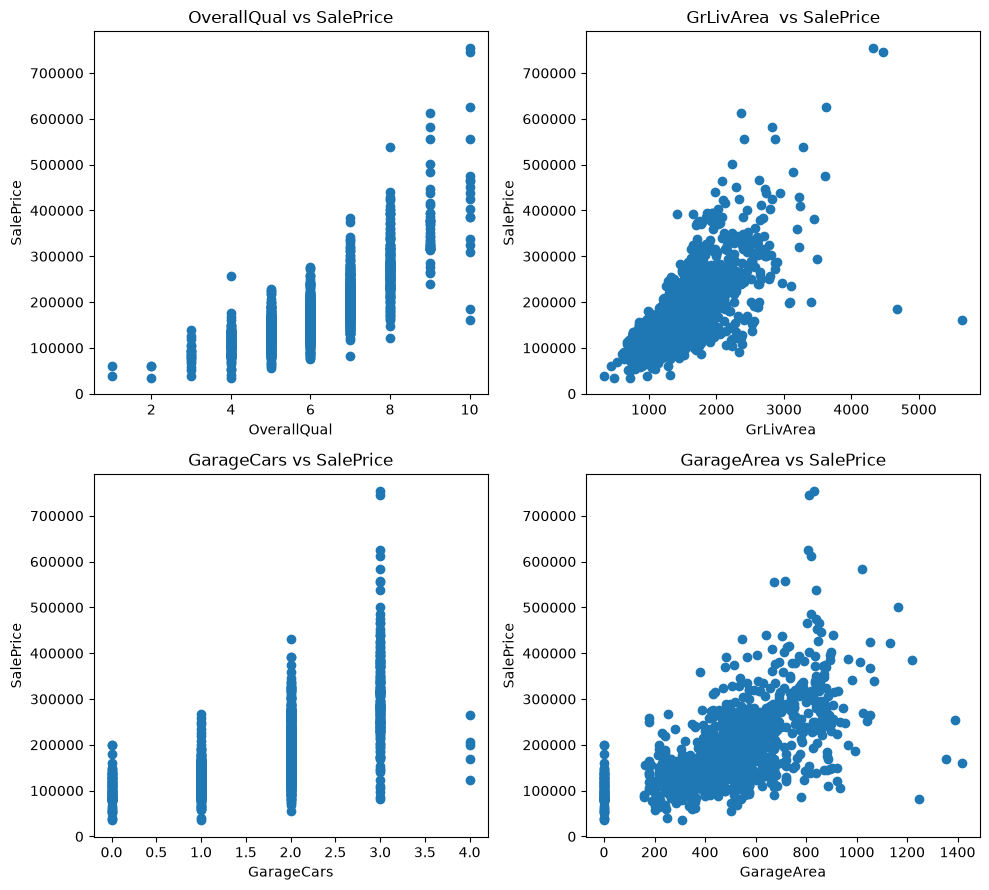

In [170]:
plt.figure(figsize=(8,6))
fig,axes=plt.subplots(2,2,figsize=(10,9))
axes[0,0].scatter(df_clean["OverallQual"],df_clean["SalePrice"])
axes[0,0].set_xlabel("OverallQual")
axes[0,0].set_ylabel("SalePrice")
axes[0,0].set_title("OverallQual vs SalePrice")

axes[0,1].scatter(df_clean["GrLivArea"],df_clean["SalePrice"])
axes[0,1].set_xlabel("GrLivArea ")
axes[0,1].set_ylabel("SalePrice")
axes[0,1].set_title("GrLivArea  vs SalePrice")

axes[1,0].scatter(df_clean["GarageCars"],df_clean["SalePrice"])
axes[1,0].set_xlabel("GarageCars")
axes[1,0].set_ylabel("SalePrice")
axes[1,0].set_title("GarageCars vs SalePrice")

axes[1,1].scatter(df_clean["GarageArea"],df_clean["SalePrice"])
axes[1,1].set_xlabel("GarageArea")
axes[1,1].set_ylabel("SalePrice")
axes[1,1].set_title("GarageArea vs SalePrice")

plt.tight_layout()# adjust space between subplots
plt.show()



In [171]:
# Number of unique categories in each categorical column
cat_unique = df_clean[categorical_col].nunique().sort_values(ascending=False)

cat_unique

Neighborhood     25
Exterior2nd      16
Exterior1st      15
SaleType          9
Condition1        9
RoofMatl          8
Condition2        8
HouseStyle        8
BsmtFinType2      7
Functional        7
GarageType        7
BsmtFinType1      7
Heating           6
Foundation        6
SaleCondition     6
RoofStyle         6
GarageQual        6
GarageCond        6
FireplaceQu       6
Electrical        5
HeatingQC         5
Fence             5
MiscFeature       5
MSZoning          5
BsmtExposure      5
BldgType          5
LotConfig         5
BsmtCond          5
BsmtQual          5
ExterCond         5
ExterQual         4
KitchenQual       4
MasVnrType        4
GarageFinish      4
PoolQC            4
LandContour       4
LotShape          4
PavedDrive        3
Alley             3
LandSlope         3
CentralAir        2
Street            2
Utilities         2
dtype: int64

In [172]:
df_clean.groupby("Neighborhood")["SalePrice"].mean().sort_values(ascending=False)
#Neighborhood strongly affects SalePrice.

Neighborhood
NoRidge    335295.317073
NridgHt    316270.623377
StoneBr    310499.000000
Timber     242247.447368
Veenker    238772.727273
Somerst    225379.837209
ClearCr    212565.428571
Crawfor    210624.725490
CollgCr    197965.773333
Blmngtn    194870.882353
Gilbert    192854.506329
NWAmes     189050.068493
SawyerW    186555.796610
Mitchel    156270.122449
NAmes      145847.080000
NPkVill    142694.444444
SWISU      142591.360000
Blueste    137500.000000
Sawyer     136793.135135
OldTown    128225.300885
Edwards    128219.700000
BrkSide    124834.051724
BrDale     104493.750000
IDOTRR     100123.783784
MeadowV     98576.470588
Name: SalePrice, dtype: float64

In [173]:
# Average SalePrice by Kitchen Quality
df_clean.groupby("KitchenQual")["SalePrice"].mean().sort_values(ascending=False)

KitchenQual
Ex    328554.670000
Gd    212116.023891
TA    139962.511565
Fa    105565.205128
Name: SalePrice, dtype: float64

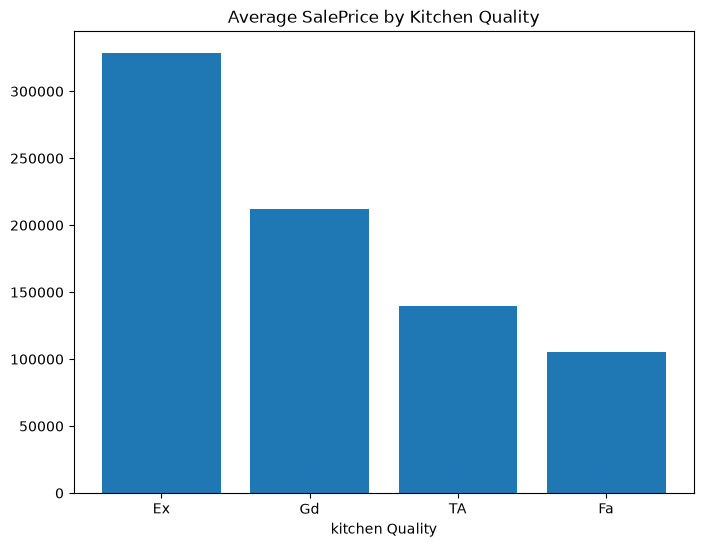

In [174]:
kitchen_prices = df_clean.groupby("KitchenQual")["SalePrice"].mean().sort_values(ascending=False)
plt.figure(figsize=(8,6))
plt.bar(kitchen_prices.index,kitchen_prices.values)
plt.xlabel("Average SalePrice")
plt.xlabel("kitchen Quality")
plt.title("Average SalePrice by Kitchen Quality")
plt.xticks(rotation=0)
plt.show()

In [175]:
# Average SalePrice by Exterior Quality
df_clean.groupby("ExterQual")["SalePrice"].mean().sort_values(ascending=False)

ExterQual
Ex    367360.961538
Gd    231633.510246
TA    144341.313466
Fa     87985.214286
Name: SalePrice, dtype: float64

In [176]:
# Numerical features selected based on correlation and domain understanding
numeric_features = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "GarageArea",
    "TotalBsmtSF",
    "1stFlrSF",
    "FullBath",
    "TotRmsAbvGrd",
    "YearBuilt",
    "YearRemodAdd"
]

# Ordinal categorical features have a meaningful order
ordinal_features = [
    "KitchenQual",
    "ExterQual",
    "BsmtQual",
    "GarageFinish",
    "CentralAir"
]

# Nominal categorical features do not have a meaningful order
nominal_features = [
    "Neighborhood",
    "GarageType"
]

In [177]:
# Combine selected features
selected_features = numeric_features + ordinal_features + nominal_features

# Create features and target
X = df_clean[selected_features].copy()
y = df_clean["SalePrice"]

In [178]:
quality_map={
   "None": 0,
    "Po": 1,
    "Fa": 2,
    "TA": 3,
    "Gd": 4,
    "Ex": 5
}
for col in["KitchenQual", "ExterQual", "BsmtQual"]:
    X[col]=X[col].map(quality_map)
# Map garage finish values to ordered numbers
garage_finish_mapping = {
    "None": 0,
    "Unf": 1,
    "RFn": 2,
    "Fin": 3
}

X["GarageFinish"] = X["GarageFinish"].map(garage_finish_mapping)
central_air_mapping={
    "N":0,
    "Y":1
}
X["CentralAir"] = X["CentralAir"].map(central_air_mapping)


In [179]:
# Apply one-hot encoding to nominal categorical features
X_encoded=pd.get_dummies(X,columns=nominal_features,drop_first=True)
X_encoded=X_encoded.astype(int)

In [180]:
# Show columns that still have missing values
X_encoded.isnull().sum()[X_encoded.isnull().sum() > 0]

Series([], dtype: int64)

In [181]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test= train_test_split(
    X_encoded,y,
    test_size=0.2,
    random_state=42
)

## Version 1: Linear Regression Baseline

In this version, I trained a basic Linear Regression model using the selected numerical, ordinal, and nominal features.

The goal of this version is to create a baseline model and understand the basic regression workflow.

Steps:
- Select important features
- Encode categorical features
- Split the data into train and test sets
- Train Linear Regression
- Evaluate using MAE, RMSE, and R² Score

In [182]:
from sklearn.linear_model import LinearRegression

In [183]:
linear_model=LinearRegression()
linear_model.fit(X_train,y_train)
y_pred=linear_model.predict(X_test)
y_pred[:10]


array([136910.58311495, 330565.58817595, 108017.09645989, 163041.11469881,
       298025.89855511,  66547.11399425, 238196.08647623, 152037.49521208,
        66404.22212504, 121178.09725051])

In [184]:
comparison=pd.DataFrame({
    "Actual Price":y_test.values,
    "Predicted Price": y_pred
})
comparison.head(10)

,Actual Price,Predicted Price
0,154500,136910.583115
1,325000,330565.588176
2,115000,108017.096460
3,159000,163041.114699
4,315500,298025.898555
5,75500,66547.113994
6,311500,238196.086476
7,146000,152037.495212
8,84500,66404.222125
9,135500,121178.097251


In [185]:
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score
import numpy as np
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)


print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 21742.006436047923
RMSE: 35290.58676565824
R2 Score: 0.8376306977534431


### Linear Regression Model

A Linear Regression model was trained using selected numerical, ordinal, and nominal features.

Categorical features were encoded before training:
- Ordinal features were manually mapped to ordered numbers.
- Nominal features were converted using One-Hot Encoding.

The model was evaluated using:
- MAE
- RMSE
- R² Score

## Version 2: Linear Regression with StandardScaler

In this version, I applied StandardScaler to the features before training Linear Regression.

The goal is to check whether scaling improves the performance of ordinary Linear Regression.

Important note:
The scaler is fitted only on the training data to avoid data leakage.

In [186]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [187]:
linear_model_scaled = LinearRegression()
linear_model_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = linear_model_scaled.predict(X_test_scaled)

mae_scaled = mean_absolute_error(y_test, y_pred_scaled)
rmse_scaled = np.sqrt(mean_squared_error(y_test, y_pred_scaled))
r2_scaled = r2_score(y_test, y_pred_scaled)

print("MAE:", mae_scaled)
print("RMSE:", rmse_scaled)
print("R2 Score:", r2_scaled)

MAE: 21742.006436047865
RMSE: 35290.58676565809
R2 Score: 0.8376306977534445


### Scaling Result

The results with scaling were almost identical to the baseline Linear Regression model.

This means that StandardScaler did not improve ordinary Linear Regression in this experiment.

This is expected because ordinary Linear Regression is usually not highly sensitive to feature scaling.

## Version 3: Decision Tree Regressor

In this version, I trained a Decision Tree Regressor.

The goal is to compare a tree-based model with Linear Regression.

Decision Trees can capture non-linear relationships, but they can also overfit the training data if not controlled.

In [188]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error ,mean_squared_error,r2_score
tree_model=DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train,y_train)
y_pred_tree=tree_model.predict(X_test)
mae_tree=mean_absolute_error(y_test,y_pred_tree)
mse_tree=mean_squared_error(y_test,y_pred_tree)
rmse_tree=np.sqrt(mse_tree)
r2_tree=r2_score(y_test,y_pred_tree)

print("Decision Tree MAE:", mae_tree)
print("Decision Tree RMSE:", rmse_tree)
print("Decision Tree R2 Score:", r2_tree)

Decision Tree MAE: 24823.328767123287
Decision Tree RMSE: 37943.34381289024
Decision Tree R2 Score: 0.8123029841476371


In [189]:
results = []
results.append({
    "Experiment": "Linear Regression Baseline",
    "MAE": mae,
    "RMSE": rmse,
    "R2 Score": r2
})
results.append({
    "Experiment": "Decision Tree Regressor",
    "MAE": mae_tree,
    "RMSE": rmse_tree,
    "R2 Score": r2_tree
})
results_df=pd.DataFrame(results)
results_df

,Experiment,MAE,RMSE,R2 Score
0,Linear Regression Baseline,21742.006436,35290.586766,0.837631
1,Decision Tree Regressor,24823.328767,37943.343813,0.812303


### Version 3 Result: Decision Tree Regressor

The Decision Tree Regressor performed worse than the Linear Regression baseline.

Linear Regression achieved lower MAE and RMSE and a higher R² Score.

This suggests that the default Decision Tree may be overfitting or not generalizing well to the test data.

## Version 4: Random Forest Regressor

In this version, I trained a Random Forest Regressor.

The goal is to improve performance by using an ensemble of multiple decision trees.

Random Forest usually performs better than a single Decision Tree because it reduces overfitting.

In [190]:
from sklearn.ensemble import RandomForestRegressor
forest_model=RandomForestRegressor(
     n_estimators=100,
     random_state=42
)
forest_model.fit(X_train,y_train)
y_pred_forest=forest_model.predict(X_test)

mae_forest=mean_absolute_error(y_test,y_pred_forest)
mse_forest=mean_squared_error(y_test,y_pred_forest)
rmse_forest=np.sqrt(mse_forest)
r2_forest=r2_score(y_test,y_pred_forest)

print("Random Forest MAE:", mae_forest)
print("Random Forest RMSE:", rmse_forest)
print("Random Forest Score:", r2_forest)

Random Forest MAE: 18378.87938992172
Random Forest RMSE: 28623.775154409734
Random Forest Score: 0.8931830952218828


In [191]:
results.append({
    "Experiment": "Random Forest Regressor",
    "MAE": mae_forest,
    "RMSE": rmse_forest,
    "R2 Score": r2_forest
})
results_df=pd.DataFrame(results)
results_df.sort_values(by="RMSE")

,Experiment,MAE,RMSE,R2 Score
2,Random Forest Regressor,18378.879390,28623.775154,0.893183
0,Linear Regression Baseline,21742.006436,35290.586766,0.837631
1,Decision Tree Regressor,24823.328767,37943.343813,0.812303


### Version 4 Result: Random Forest Regressor

Random Forest achieved the best performance so far.

Compared with Linear Regression and Decision Tree, Random Forest produced:
- Lower MAE
- Lower RMSE
- Higher R² Score

This means Random Forest made smaller prediction errors and explained more variance in SalePrice.

Random Forest performed better because it can capture non-linear relationships and feature interactions better than Linear Regression.

## Version 5: Adding More Features

In this version, I will add more numerical and categorical features to check whether more information improves model performance.

Features are selected based on:
- Correlation with SalePrice
- EDA results
- Domain understanding

The new model will be compared with the previous best model: Random Forest Regressor.

In [192]:
more_numeric_features = [
    "LotArea",
    "LotFrontage",
    "MasVnrArea",
    "Fireplaces",
    "WoodDeckSF",
    "OpenPorchSF",
    "BsmtFullBath",
    "HalfBath",
    "BedroomAbvGr",
    "OverallCond"
]
more_ordinal_features = [
    "HeatingQC",
    "GarageQual",
    "GarageCond",
    "FireplaceQu"
]

more_nominal_features = [
    "MSZoning",
    "HouseStyle",
    "Foundation",
    "SaleCondition",
    "PavedDrive",
    "BldgType"
]

# Version 5: Add more features

numeric_features_v2 =numeric_features + more_numeric_features

ordinal_features_v2 = ordinal_features + more_ordinal_features

nominal_features_v2 = nominal_features + more_nominal_features

selected_features_v2 = numeric_features_v2 + ordinal_features_v2 + nominal_features_v2

X_v2 = df_clean[selected_features_v2].copy()
y_v2 = df_clean["SalePrice"]

In [193]:
# Apply ordinal encoding to quality-related columns
quality_cols_v2 = [
    "KitchenQual",
    "ExterQual",
    "BsmtQual",
    "HeatingQC",
    "GarageQual",
    "GarageCond",
    "FireplaceQu"
]

for col in quality_cols_v2:
    X_v2[col] = X_v2[col].map(quality_map)

# Apply ordinal encoding to GarageFinish
X_v2["GarageFinish"] = X_v2["GarageFinish"].map(garage_finish_mapping)

# Apply binary encoding to CentralAir
X_v2["CentralAir"] = X_v2["CentralAir"].map(central_air_mapping)

In [194]:
# Apply one-hot encoding to nominal categorical features
X_v2 = pd.get_dummies(
    X_v2,
    columns=nominal_features_v2,
    drop_first=True
)

In [195]:
from sklearn.model_selection import train_test_split

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2,
    y_v2,
    test_size=0.2,
    random_state=42
)

print("X_train_v2 shape:", X_train_v2.shape)
print("X_test_v2 shape:", X_test_v2.shape)

X_train_v2 shape: (1168, 86)
X_test_v2 shape: (292, 86)


In [196]:
from sklearn.ensemble import RandomForestRegressor

# Train Random Forest with more features
forest_model_v2 = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

forest_model_v2.fit(X_train_v2, y_train_v2)

# Make predictions
y_pred_forest_v2 = forest_model_v2.predict(X_test_v2)

# Evaluate
mae_forest_v2 = mean_absolute_error(y_test_v2, y_pred_forest_v2)
rmse_forest_v2 = np.sqrt(mean_squared_error(y_test_v2, y_pred_forest_v2))
r2_forest_v2 = r2_score(y_test_v2, y_pred_forest_v2)

print("Random Forest V2 MAE:", mae_forest_v2)
print("Random Forest V2 RMSE:", rmse_forest_v2)
print("Random Forest V2 R2 Score:", r2_forest_v2)

Random Forest V2 MAE: 17603.632751141555
Random Forest V2 RMSE: 28692.326126075663
Random Forest V2 R2 Score: 0.8926708517619895


In [197]:
results.append({
    "Experiment": "Random Forest + More Features",
    "MAE": mae_forest_v2,
    "RMSE": rmse_forest_v2,
    "R2 Score": r2_forest_v2
})

results_df = pd.DataFrame(results)
results_df.sort_values(by="RMSE")

,Experiment,MAE,RMSE,R2 Score
2,Random Forest Regressor,18378.879390,28623.775154,0.893183
3,Random Forest + More Features,17603.632751,28692.326126,0.892671
0,Linear Regression Baseline,21742.006436,35290.586766,0.837631
1,Decision Tree Regressor,24823.328767,37943.343813,0.812303


## Version 6: Handling Outliers

In this version, I investigated extreme outliers, especially houses with very large living area but relatively low sale price.

The goal is to check whether removing extreme outliers improves model performance.

Outliers should not be removed randomly. They must be analyzed first.

In [198]:
# Check houses with very large living area but relatively low sale price
outliers = df_clean[(df_clean["GrLivArea"] > 4000) & (df_clean["SalePrice"] < 300000)]

outliers[["Id", "GrLivArea", "SalePrice", "OverallQual", "Neighborhood"]]
df_no_outliers=df_clean.drop(index=outliers.index)
print("Original shape:", df_clean.shape)
print("After removing outliers:", df_no_outliers.shape)

Original shape: (1460, 81)
After removing outliers: (1458, 81)


In [199]:
X_out = df_no_outliers[selected_features_v2].copy()
y_out = df_no_outliers["SalePrice"]

In [200]:
for col in quality_cols_v2:
    X_out[col] = X_out[col].map(quality_map)

X_out["GarageFinish"] = X_out["GarageFinish"].map(garage_finish_mapping)

X_out["CentralAir"] = X_out["CentralAir"].map(central_air_mapping)

In [201]:
X_out_encoded=pd.get_dummies(
    X_out, 
    columns=nominal_features_v2,
    drop_first=True
)


In [202]:
X_train_out,X_test_out,y_train_out,y_test_out=train_test_split(
    X_out_encoded,
    y_out,
    test_size=0.2,
    random_state=42
)

In [203]:
forest_model_out = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

forest_model_out.fit(X_train_out, y_train_out)
y_pred_out = forest_model_out.predict(X_test_out)


mae_out = mean_absolute_error(y_test_out, y_pred_out)
rmse_out = np.sqrt(mean_squared_error(y_test_out, y_pred_out))
r2_out = r2_score(y_test_out, y_pred_out)

results.append({
    "Experiment":  "Random Forest + More Features + No Outliers",
    "MAE": mae_out,
    "RMSE": rmse_out,
    "R2 Score": r2_out
})
results_df=pd.DataFrame(results)
results_df.sort_values(by="RMSE")

,Experiment,MAE,RMSE,R2 Score
4,Random Forest + More Features + No Outliers,17403.260856,24996.456843,0.886884
2,Random Forest Regressor,18378.879390,28623.775154,0.893183
3,Random Forest + More Features,17603.632751,28692.326126,0.892671
0,Linear Regression Baseline,21742.006436,35290.586766,0.837631
1,Decision Tree Regressor,24823.328767,37943.343813,0.812303


### Version 6 Result

Random Forest + More Features + No Outliers improved because the two extreme outliers were removed.

These outliers had very large living areas and high overall quality, but unusually low sale prices.  
Removing them helped the model learn a cleaner relationship between house features and SalePrice.

As a result, MAE and RMSE decreased, which means the model made smaller prediction errors, especially fewer large errors.

## Version 7: Log Transformation of SalePrice

In this version, I applied log transformation to the target variable SalePrice.

The target distribution is right-skewed, so log transformation may help the model learn better patterns.

After prediction, the values will be converted back to the original price scale.

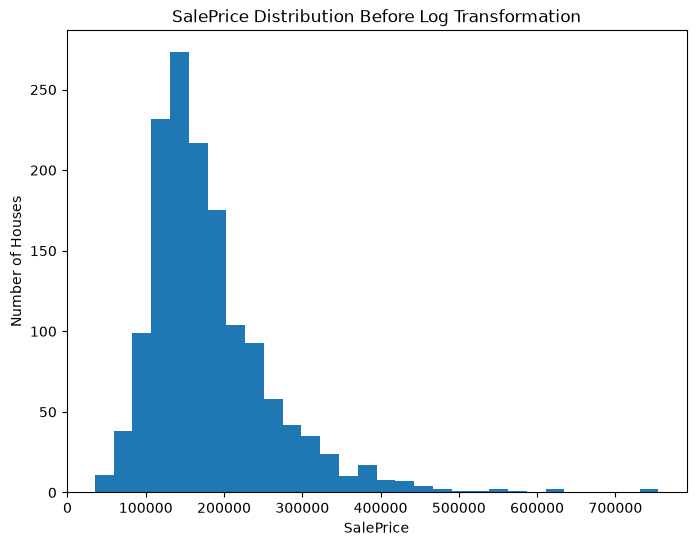

In [204]:
# Compare SalePrice distribution before and after log transformation
plt.figure(figsize=(8,6))
plt.hist(df_no_outliers["SalePrice"],bins=30)
plt.xlabel("SalePrice")
plt.ylabel("Number of Houses")
plt.title("SalePrice Distribution Before Log Transformation")
plt.show()

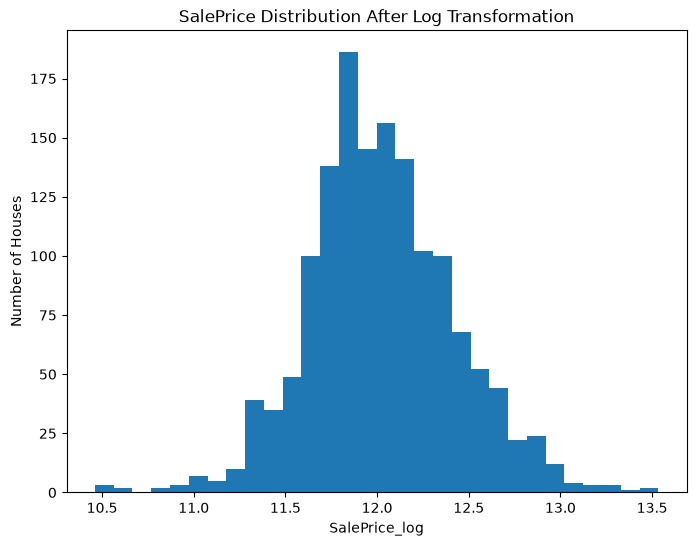

In [205]:
# Compare SalePrice distribution before and after log transformation
SalePrice_log=np.log1p(df_no_outliers["SalePrice"])
plt.figure(figsize=(8,6))
plt.hist(SalePrice_log,bins=30)
plt.xlabel("SalePrice_log")
plt.ylabel("Number of Houses")
plt.title("SalePrice Distribution After Log Transformation")
plt.show()

In [206]:
X_log=X_out_encoded.copy()
y_original = df_no_outliers["SalePrice"]
y_log=np.log1p(y_original)

X_train_log, X_test_log, y_train_log, y_test_log, y_train_original, y_test_original = train_test_split(
    X_log,
    y_log,
    y_original,
    test_size=0.2,
    random_state=42
)


In [207]:
forest_model_log = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
forest_model_log.fit(X_train_log,y_train_log)
y_pred_log=forest_model_log.predict(X_test_log)

# Convert predictions back to original price scale
y_pred_original = np.expm1(y_pred_log)

# Evaluate predictions on the original price scale
mae_log = mean_absolute_error(y_test_original, y_pred_original)
rmse_log = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
r2_log = r2_score(y_test_original, y_pred_original)

results.append({
    "Experiment": "Log Target+No Outliers+More Features+Random Forest",
    "MAE": mae_log,
    "RMSE": rmse_log,
    "R2 Score": r2_log
})

results_df = pd.DataFrame(results)
results_df.sort_values(by="RMSE")

,Experiment,MAE,RMSE,R2 Score
5,Log Target+No Outliers+More Features+Random Fo...,16807.131918,24413.650245,0.892097
4,Random Forest + More Features + No Outliers,17403.260856,24996.456843,0.886884
2,Random Forest Regressor,18378.879390,28623.775154,0.893183
3,Random Forest + More Features,17603.632751,28692.326126,0.892671
0,Linear Regression Baseline,21742.006436,35290.586766,0.837631
1,Decision Tree Regressor,24823.328767,37943.343813,0.812303


### Version 7 Result: Log Transformation

Log transformation improved the model performance.

After applying log transformation to SalePrice, the model achieved lower MAE, lower RMSE, and a higher R² Score compared with the previous no-outliers version.

This improvement happened because SalePrice was right-skewed, and log transformation reduced the effect of very expensive houses.

Overall, Random Forest with more features, no extreme outliers, and log-transformed target is the best model so far.

## Version 8: Cross Validation

In this version, I used Cross Validation to evaluate the model more reliably.

Instead of relying on only one train/test split, Cross Validation tests the model on multiple splits and gives a more stable performance estimate.

In [226]:
from sklearn.model_selection import KFold
X_cv=X_out_encoded.copy()
y_cv_original=df_no_outliers["SalePrice"]
y_cv_log=np.log1p(y_cv_original)

kf=KFold(n_splits=5,shuffle=True,random_state=42)
mae_scores=[]
rmse_scores=[]
r2_scores=[]

In [227]:
# Perform manual cross validation
# kf.split(X_cv) gives row indices only; we use the same indices to split both X and y so features and target stay matched.
for train_index,test_index in kf.split(X_cv):
    X_train_fold=X_cv.iloc[train_index]
    X_test_fold=X_cv.iloc[test_index]

    y_train_fold_log=y_cv_log.iloc[train_index]
    y_test_fold_original=y_cv_original.iloc[test_index]

    model_cv= RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )
    model_cv.fit(X_train_fold,y_train_fold_log)
    y_pred_fold_log=model_cv.predict(X_test_fold)
    y_pred_fold_original=np.expm1(y_pred_fold_log)

    mae_fold = mean_absolute_error(y_test_fold_original, y_pred_fold_original)
    rmse_fold = np.sqrt(mean_squared_error(y_test_fold_original, y_pred_fold_original))
    r2_fold = r2_score(y_test_fold_original, y_pred_fold_original)

    mae_scores.append(mae_fold)
    rmse_scores.append(rmse_fold)
    r2_scores.append(r2_fold)
    

In [228]:
cv_mae_mean=np.mean(mae_scores)
cv_rmse_mean=np.mean(rmse_scores)
cv_r2_mean=np.mean(r2_scores)

cv_mae_std=np.std(mae_scores)
cv_rmse_std=np.std(rmse_scores)
cv_r2_std=np.std(r2_scores)

print("Cross Validation MAE Mean:", cv_mae_mean)
print("Cross Validation MAE Std:", cv_mae_std)

print("Cross Validation RMSE Mean:", cv_rmse_mean)
print("Cross Validation RMSE Std:", cv_rmse_std)

print("Cross Validation R2 Mean:", cv_r2_mean)
print("Cross Validation R2 Std:", cv_r2_std)

Cross Validation MAE Mean: 17537.900301467576
Cross Validation MAE Std: 526.8113528134187
Cross Validation RMSE Mean: 27878.093034102338
Cross Validation RMSE Std: 1800.7554437176843
Cross Validation R2 Mean: 0.8759298706267711
Cross Validation R2 Std: 0.011701840737997708


In [229]:
cv_results = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "MAE": mae_scores,
    "RMSE": rmse_scores,
    "R2 Score": r2_scores
})

cv_results

,Fold,MAE,RMSE,R2 Score
0,1,16841.123501,24734.832709,0.889239
1,2,17189.860751,28046.147736,0.887989
2,3,18237.441267,27486.388209,0.858249
3,4,18051.167162,30053.380205,0.875243
4,5,17369.908827,29069.716312,0.868928


In [230]:
cv_summary = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2 Score"],
    "Mean": [cv_mae_mean, cv_rmse_mean, cv_r2_mean],
    "Std": [cv_mae_std, cv_rmse_std, cv_r2_std]
})

cv_summary

,Metric,Mean,Std
0,MAE,17537.900301,526.811353
1,RMSE,27878.093034,1800.755444
2,R2 Score,0.875930,0.011702


### Version 8 Result: Cross Validation

Cross Validation was used to evaluate the best model more reliably.

Instead of depending on one train/test split, the model was trained and tested on 5 different folds.

Because the model was trained on log-transformed SalePrice, predictions were converted back to the original price scale using `np.expm1()` before evaluation.

The mean scores show the average model performance, while the standard deviation shows how stable the model is across different splits.



Cross Validation gave a more reliable estimate of the model performance.

The model achieved an average MAE of about 17,538, meaning the average prediction error is around 17.5k across different folds.

The average RMSE was about 27,878, which shows that some larger errors still exist.

The average R² Score was about 0.876, meaning the model explains around 87.6% of the variation in SalePrice across different data splits.

The standard deviations are relatively small, especially for MAE and R², which suggests that the model performance is fairly stable.

## Version 9: Hyperparameter Tuning

In this version, I tuned the model hyperparameters to improve performance.

The goal is to find better model settings instead of using the default values.

## Version 10: Pipeline

In this version, I used a Pipeline to combine preprocessing and model training in one clean workflow.

This makes the project more professional, easier to maintain, and safer from data leakage.